# Accelerating LLM Inference with KV-Cache

I will:
- Explain the concept of Key-Value (KV) caching in self-attention.
- Implement baseline attention (no cache) in PyTorch.
- Implement KV-cache for inference-time speedups.
- Benchmark generation with and without cache.
- Optionally compare with Hugging Face GPT-2 using `use_cache`.

<a href="https://ibb.co/p6MkDkJp"><img src="https://i.ibb.co/Fkydvdgt/kv-cache.png" alt="kv-cache" border="0"></a>

Notes:
- I intentionally avoid pinning dependency versions and will install latest available releases.
- The demo models are small and untrained; the goal is to measure speed behavior, not output quality.
- For reproducibility and simple CPU/GPU compatibility, I keep the model small by default.

## 1) Environment setup
This installs required packages without explicit version pins, per your request.

In [1]:
import sys, subprocess, pkgutil
def pip_install(pkg):
    if pkg.replace('-', '_') not in {m.name for m in pkgutil.iter_modules()}:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

# Install latest (no version pins)
for p in ['torch', 'matplotlib', 'numpy', 'transformers', 'tqdm', 'requests']:
    try:
        pip_install(p)
    except Exception as e:
        print(f'Warning: could not ensure install for {p}: {e}')

In [2]:
import math, time, os, json
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## 2) Data preparation (Tiny Shakespeare)
I'll fetch the tiny Shakespeare dataset used frequently for character-level language modeling demos.
If the file is not present, I will download it automatically.

In [3]:
import requests
data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
data_path = Path('input.txt')
if not data_path.exists():
    r = requests.get(data_url, timeout=30)
    r.raise_for_status()
    data_path.write_text(r.text, encoding='utf-8')

text = data_path.read_text(encoding='utf-8')
len(text), text[:200]

(1115394,
 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you')

In [4]:
# Build character-level vocab
vocab = sorted(list(set(text)))
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for i, ch in enumerate(vocab)}

def encode(s):
    return [stoi[c] for c in s]

def decode(ixs):
    return ''.join(itos[i] for i in ixs)

data = torch.tensor(encode(text), dtype=torch.long)
split = int(0.9 * len(data))
train, val = data[:split], data[split:]
vocab_size = len(vocab)
vocab_size

65

## 3) Self-attention recap (no cache)
I implement a minimal Transformer block stack with multi-head self-attention.

Shapes:
- Input tokens: `(B, T)`
- Embeddings: `(B, T, C)`
- Attention per head: queries/keys/values `(B, T, head_size)`
- Attention weights: `(B, T, T)` with causal mask

This baseline recomputes keys/values for the entire prefix at every generation step, which becomes costly as T grows.

In [5]:
# Hyperparameters (small by default)
block_size = 256   # context length
embed_size = 128
num_heads  = 4
num_layers = 2
dropout    = 0.0

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(embed_size, head_size, bias=False)
        self.query = nn.Linear(embed_size, head_size, bias=False)
        self.value = nn.Linear(embed_size, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(1, 2) / math.sqrt(self.head_size)  # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ v  # (B, T, head_size)
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads):
        super().__init__()
        head_size = embed_size // num_heads
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(embed_size, embed_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = torch.cat([h(x) for h in self.heads], dim=-1)
        x = self.dropout(self.proj(x))
        return x

class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_size, 4 * embed_size),
            nn.ReLU(),
            nn.Linear(4 * embed_size, embed_size),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.sa = MultiHeadAttention(num_heads)
        self.ff = FeedForward()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class BaselineModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_size)
        self.pos_emb   = nn.Embedding(block_size, embed_size)
        self.blocks    = nn.Sequential(*[Block() for _ in range(num_layers)])
        self.ln_f      = nn.LayerNorm(embed_size)
        self.head      = nn.Linear(embed_size, vocab_size)

    def forward(self, idx):
        B, T = idx.shape
        tok = self.token_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=idx.device))
        x = tok + pos
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        # Recompute over the entire prefix each step (no cache).
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]  # crop to context window
            logits = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_idx], dim=1)
        return idx

baseline = BaselineModel(vocab_size).to(device)
baseline

BaselineModel(
  (token_emb): Embedding(65, 128)
  (pos_emb): Embedding(256, 128)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=128, out_features=32, bias=False)
            (query): Linear(in_features=128, out_features=32, bias=False)
            (value): Linear(in_features=128, out_features=32, bias=False)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=128, bias=True)
          (3): Dropout(p=0.0, inplace=False)
        )
      )
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((128,)

## 4) KV-Cache: concept and implementation
KV-cache stores previously computed Keys and Values and reuses them across autoregressive steps.

Key ideas during generation:
- Feed only one new token per step.
- Append its K/V to cache; queries attend to cached keys/values.
- Complexity per step becomes roughly constant (depends on max context), rather than growing with sequence length recomputation.

Below I implement cached attention heads with fixed-size caches of shape `(B, block_size, head_size)`.

In [7]:
class CachedHead(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(embed_size, head_size, bias=False)
        self.query = nn.Linear(embed_size, head_size, bias=False)
        self.value = nn.Linear(embed_size, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size
        # Caches allocated lazily on first use
        self.k_cache = None
        self.v_cache = None
        self.cache_index = 0

    def reset_cache(self):
        self.k_cache = None
        self.v_cache = None
        self.cache_index = 0

    def forward(self, x, caching=False):
        B, T, C = x.shape  # typically T==1 during cached generation
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        if not caching:
            # Baseline path (full prefix, causal mask)
            wei = q @ k.transpose(1, 2) / math.sqrt(self.head_size)
            tril = torch.tril(torch.ones(T, T, device=x.device))
            wei = wei.masked_fill(tril == 0, float('-inf'))
            wei = F.softmax(wei, dim=-1)
            wei = self.dropout(wei)
            out = wei @ v
            return out

        # Cached path: append new K/V and attend over all cached keys
        if self.k_cache is None or self.v_cache is None:
            self.k_cache = torch.zeros(B, block_size, self.head_size, device=x.device)
            self.v_cache = torch.zeros(B, block_size, self.head_size, device=x.device)
            self.cache_index = 0

        # Place new K/V into cache (rolling if needed)
        if self.cache_index + T <= block_size:
            self.k_cache[:, self.cache_index:self.cache_index+T, :] = k
            self.v_cache[:, self.cache_index:self.cache_index+T, :] = v
        else:
            shift = self.cache_index + T - block_size
            self.k_cache[:, :-shift, :] = self.k_cache[:, shift:, :].clone()
            self.v_cache[:, :-shift, :] = self.v_cache[:, shift:, :].clone()
            self.k_cache[:, -T:, :] = k
            self.v_cache[:, -T:, :] = v

        self.cache_index = min(self.cache_index + T, block_size)

        # Query attends over cached keys: shape (B, 1, cache_len)
        wei = q @ self.k_cache.transpose(1, 2) / math.sqrt(self.head_size)
        wei = F.softmax(wei[:, :, :self.cache_index], dim=-1)
        wei = self.dropout(wei)
        out = wei @ self.v_cache[:, :self.cache_index, :]
        return out

class CachedMultiHeadAttention(nn.Module):
    def __init__(self, num_heads):
        super().__init__()
        head_size = embed_size // num_heads
        self.heads = nn.ModuleList([CachedHead(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(embed_size, embed_size)
        self.dropout = nn.Dropout(dropout)

    def reset_cache(self):
        for h in self.heads:
            h.reset_cache()

    def forward(self, x, caching=False):
        if caching:
            x = torch.cat([h(x, caching=True) for h in self.heads], dim=-1)
        else:
            x = torch.cat([h(x, caching=False) for h in self.heads], dim=-1)
        x = self.dropout(self.proj(x))
        return x

class CachedBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.sa = CachedMultiHeadAttention(num_heads)
        self.ff = FeedForward()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)
    def reset_cache(self):
        self.sa.reset_cache()
    def forward(self, x, caching=False):
        x = x + self.sa(self.ln1(x), caching=caching)
        x = x + self.ff(self.ln2(x))
        return x

class KVCacheModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_size)
        self.pos_emb   = nn.Embedding(block_size, embed_size)
        self.blocks    = nn.ModuleList([CachedBlock() for _ in range(num_layers)])
        self.ln_f      = nn.LayerNorm(embed_size)
        self.head      = nn.Linear(embed_size, vocab_size)

    def reset_cache(self):
        for b in self.blocks:
            b.reset_cache()

    def forward(self, idx, caching=False):
        B, T = idx.shape
        tok = self.token_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=idx.device))
        x = tok + pos
        for b in self.blocks:
            x = b(x, caching=caching)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits

    @torch.no_grad()
    def generate_cached(self, idx, max_new_tokens):
        # One token at a time; reuse K/V
        self.eval()
        self.reset_cache()
        for _ in range(max_new_tokens):
            # Only last token as input (T==1)
            x = idx[:, -1:]
            logits = self(x, caching=True)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_idx], dim=1)
        return idx

kvmodel = KVCacheModel(vocab_size).to(device)
kvmodel

KVCacheModel(
  (token_emb): Embedding(65, 128)
  (pos_emb): Embedding(256, 128)
  (blocks): ModuleList(
    (0-1): 2 x CachedBlock(
      (sa): CachedMultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x CachedHead(
            (key): Linear(in_features=128, out_features=32, bias=False)
            (query): Linear(in_features=128, out_features=32, bias=False)
            (value): Linear(in_features=128, out_features=32, bias=False)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=128, bias=True)
          (3): Dropout(p=0.0, inplace=False)
        )
      )
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      

## 5) Benchmark: generation with vs without cache
I generate multiple tokens and measure wall-clock time for both models.
Cache benefits grow with longer sequences and larger models. For small settings, differences may be modest.

In [8]:
def benchmark_models(start_text='Once upon a time ', steps_list=(100, 300, 600)):
    results = []
    with torch.no_grad():
        for steps in steps_list:
            # Prepare initial context of length 1 from start_text (last char)
            x = torch.tensor([[stoi[start_text[-1]]]], dtype=torch.long, device=device)

            t0 = time.time()
            out1 = baseline.generate(x.clone(), max_new_tokens=steps)
            t1 = time.time() - t0

            t0 = time.time()
            out2 = kvmodel.generate_cached(x.clone(), max_new_tokens=steps)
            t2 = time.time() - t0

            results.append((steps, t1, t2))
    return results

results = benchmark_models(steps_list=(100, 300, 600))
results

[(100, 0.5248942375183105, 0.26172447204589844),
 (300, 2.1557979583740234, 0.7557156085968018),
 (600, 6.831579923629761, 1.626772165298462)]

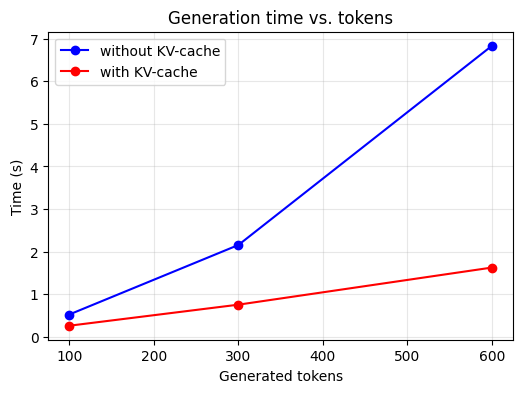

In [9]:
# Visualize timings
steps = [r[0] for r in results]
no_cache = [r[1] for r in results]
with_cache = [r[2] for r in results]

plt.figure(figsize=(6,4))
plt.plot(steps, no_cache, 'o-b', label='without KV-cache')
plt.plot(steps, with_cache, 'o-r', label='with KV-cache')
plt.xlabel('Generated tokens')
plt.ylabel('Time (s)')
plt.title('Generation time vs. tokens')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpreting results
- For small models and short sequences, speedups may be moderate.
- As sequence length and embedding size grow, recomputation overhead dominates the baseline, and KV-cache yields larger gains.
- In practical deployments, pair KV-cache with optimized kernels and batching for best effects.

## 6) Optional: Compare `use_cache` in Hugging Face GPT-2
I can replicate a quick demo using a pretrained model. This can be slow on CPU and will download weights.
Set `run_demo=True` to proceed.

In [10]:
import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# set to True to actually run the demo (will download weights)
run_demo = True

def gpt2_compare(prompt='Once upon a time', max_new_tokens=200, model_name='gpt2', device=None):
    """
    Returns: (text_without_cache, time_without_cache, text_with_cache, time_with_cache)
    """
    # choose device if not provided
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # load tokenizer + model
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # gpt2 tokenizer doesn't have a pad_token by default; set it to eos_token to avoid warnings
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
        model.config.pad_token_id = tok.eos_token_id

    # prepare input
    inp = tok(prompt, return_tensors='pt').input_ids.to(device)

    with torch.no_grad():
        # warm-up (optional, helps make timing more stable)
        _ = model.generate(inp, use_cache=True, max_new_tokens=1)

        # no cache
        t0 = time.time()
        out_no_cache = model.generate(inp, use_cache=False, max_new_tokens=max_new_tokens)
        t_no = time.time() - t0

        # with cache
        t0 = time.time()
        out_with_cache = model.generate(inp, use_cache=True, max_new_tokens=max_new_tokens)
        t_yes = time.time() - t0

    # decode to text
    text_no = tok.decode(out_no_cache[0], skip_special_tokens=True)
    text_yes = tok.decode(out_with_cache[0], skip_special_tokens=True)

    return text_no, t_no, text_yes, t_yes

if __name__ == "__main__":
    if run_demo:
        prompt = "Once upon a time"
        text_no, t_no, text_yes, t_yes = gpt2_compare(prompt=prompt, max_new_tokens=200)
        print(f"Prompt: {prompt!r}")
        print("Without KV Cache time (s):", round(t_no, 4))
        print("With    KV Cache time (s):", round(t_yes, 4))
        print("\n--- Output (with cache) ---\n")
        print(text_yes[:1000])  # show up to first 1000 chars
    else:
        print("Skipped GPT-2 demo. Set run_demo = True to run (this will download model weights).")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: 'Once upon a time'
Without KV Cache time (s): 88.3237
With    KV Cache time (s): 12.3432

--- Output (with cache) ---

Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a pl

## 7) Practical notes and pitfalls
- **Cache size vs. context length**: Ensure cache arrays match the maximum context you expect; roll or evict when full.
- **Batching**: When generating multiple sequences, maintain per-sequence cache indices.
- **Memory footprint**: KV tensors can be large for big models; consider quantization or paged KV caches.
- **Quality vs. speed**: Caching changes compute paths at inference but not model quality; quality depends on training, not the cache itself.
- **Framework kernels**: Real-world systems exploit fused kernels and efficient layouts for additional gains beyond Python-level demos.

The main takeaway: KV-cache avoids redundant recomputation of K/V across autoregressive steps, often yielding substantial latency reductions for long generations and larger models.